# NumPy 예제 70선 (대분류 · 중분류 · 문제)

공식 문서 **[Absolute beginners](https://numpy.org/doc/stable/user/absolute_beginners.html)** 와 **[Quickstart](https://numpy.org/doc/stable/user/quickstart.html)** 를 바탕으로 구성했습니다.

- **문제 1~60**: 배열 기초·연산·Quickstart 계열.
- **문제 61~70**: **문제 61 한 번만** `정형_csv` + **`pandas.read_csv` → `to_numpy()`** 로 `X`, `SRV`, `ISSUE_CAT` 를 만듭니다. **문제 62~70은 추가 파일 입출력 없이 NumPy만**으로 가공합니다(위 셀을 먼저 실행).
- 각 문제는 **`#` 대분류 → `##` 중분류 → `### 문제 N`** 순으로 표시됩니다.
- **`-` 불릿**에 해당 코드에서 쓰는 **주요 메서드·개념**을 적었습니다.
- **코드 셀**에는 한국어 **`#` 주석**을 달았습니다.


# I. NumPy 시작과 1차원 배열

## 1.1 가져오기·생성

### 문제 1. `import numpy as np` 관례와 버전

- **`import numpy as np`**: 공식 문서에서 권장하는 관례로, `np` 접두어로 함수·클래스를 구분합니다.

- **`numpy.__version__`**: 현재 환경에 설치된 NumPy 버전 문자열입니다.


In [2]:
# ── NumPy 버전 확인 ───────────────────────────────────────────────────
# 환경 재현성 점검

import numpy as np  # NumPy를 짧은 이름 np로 가져옴

# 설치된 버전 확인 (재현성·호환성 점검에 유용)
print("NumPy version:", np.__version__)


NumPy version: 2.4.4


### 문제 2. 리스트에서 `np.array`로 1차원 배열 만들기

- **`np.array(object, dtype=...)`**: 시퀀스(리스트 등)를 복사해 `ndarray`를 만듭니다. 원소 타입에 맞춰 `dtype`이 정해집니다.

- **동질성**: 한 배열 안의 원소는 보통 같은 타입으로 맞춰집니다(업캐스팅).


In [2]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

# Python 리스트 → ndarray (값 복사)
a = np.array([1, 2, 3, 4, 5, 6])
print(a)
print("dtype:", a.dtype)


[1 2 3 4 5 6]
dtype: int64


## 1.2 인덱싱·가변성·슬라이스

### 문제 3. 0부터 시작하는 인덱스 `a[0]`

- **0-based 인덱싱**: 첫 원소는 인덱스 `0`입니다(파이썬 시퀀스와 동일).

- **`a[i]`**: 1차원 배열에서 i번째 원소를 읽습니다.


In [3]:
# ── 슬라이싱·인덱싱 ──────────────────────────────────────────────────────
# 부분 구간·요소 접근

import numpy as np

a = np.array([10, 20, 30])
print("첫 원소:", a[0])  # 인덱스 0
print("마지막:", a[-1])  # 음수 인덱스도 가능


첫 원소: 10
마지막: 30


### 문제 4. 원소 수정(가변, mutable)

- **in-place 변경**: `a[i] = 값`으로 원소를 바꿀 수 있습니다.

- **리스트와 유사**: 인덱스로 특정 위치만 갱신합니다.


In [4]:
# ── 슬라이싱·인덱싱 ──────────────────────────────────────────────────────
# 부분 구간·요소 접근

import numpy as np

a = np.array([1, 2, 3, 4, 5, 6])
a[0] = 10  # 첫 원소만 교체
print(a)


[10  2  3  4  5  6]


### 문제 5. 슬라이스 `a[:3]`

- **슬라이스 문법**: `[시작:끝:간격]` — 끝 인덱스는 포함되지 않습니다.

- **`a[:3]`**: 인덱스 0,1,2까지(3 미포함).


In [5]:
# ── 슬라이싱·인덱싱 ──────────────────────────────────────────────────────
# 부분 구간·요소 접근

import numpy as np

a = np.array([10, 2, 3, 4, 5, 6])
print(a[:3])  # 앞에서 3개
print(a[2:])  # 인덱스 2부터 끝까지


[10  2  3]
[3 4 5 6]


### 문제 6. 슬라이스는 보통 뷰(view) — 원본과 메모리 공유

- **뷰(view)**: 슬라이스 결과가 원본과 같은 데이터 버퍼를 보면, 한쪽 수정이 다른쪽에 반영될 수 있습니다.

- **리스트와 차이**: 파이썬 리스트의 슬라이스는 보통 새 리스트(복사)입니다.


In [6]:
# ── 슬라이싱·인덱싱 ──────────────────────────────────────────────────────
# 부분 구간·요소 접근

import numpy as np

a = np.array([10, 2, 3, 4, 5, 6])
b = a[3:]  # 인덱스 3부터 끝까지 (뷰인 경우가 많음)
b[0] = 40  # 뷰를 통해 원본도 같이 바뀔 수 있음
print("a:", a)
print("b:", b)


a: [10  2  3 40  5  6]
b: [40  5  6]


# II. 다차원 배열과 축(axis)

## 2.1 2차원 배열·인덱스

### 문제 7. 중첩 리스트로 2차원 배열 만들기

- **`np.array` 중첩**: 바깥 리스트가 첫 번째 축(행), 안쪽이 두 번째 축(열)에 대응합니다.

- **직사각형**: 각 행의 길이가 같아야 합니다.


In [7]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

# 3행 4열 2차원 배열
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
print(a)
print("shape (행, 열):", a.shape)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
shape (행, 열): (3, 4)


### 문제 8. 쉼표로 축 지정 `a[행, 열]` — `a[1, 3]`

- **다차원 인덱싱**: `a[i, j]`는 i번째 행, j번째 열의 원소입니다.

- **콤마**: 한 쌍의 `[]` 안에서 축을 나열합니다.


In [8]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
print("행1 열3:", a[1, 3])  # 값 8


행1 열3: 8


### 문제 9. 축(axis)과 `ndim` — ‘데이터 차원’과 구분

- **`ndim`**: 배열이 가진 축의 개수(스칼라는 0, 벡터는 1, 행렬은 2…).

- **축 번호**: `axis=0`은 첫 번째 축(보통 행 방향), `axis=1`은 두 번째 축(열 방향)으로 해석하는 경우가 많습니다.


In [9]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
print("ndim (축 개수):", a.ndim)
print("shape:", a.shape)


ndim (축 개수): 2
shape: (3, 4)


## 2.2 배열 속성 한 번에 보기

### 문제 10. `ndim`, `shape`, `size`, `dtype`, `itemsize`, `nbytes`

- **`a.shape`**: 각 축 길이의 튜플. `len(shape)==ndim`입니다.

- **`a.size`**: 원소 총개수. 보통 `shape`의 곱과 같습니다.

- **`a.dtype`**: 원소의 데이터 타입(`int64`, `float64` 등).

- **`a.itemsize`**: 원소 한 개가 차지하는 바이트 수.

- **`a.nbytes`**: 데이터 영역 전체 바이트(대략 `size * itemsize`).


In [10]:
# ── reshape ───────────────────────────────────────────────────────
# 배열 `shape` 변경

import numpy as np
import math

a = np.arange(12).reshape(3, 4)  # 0..11 을 3x4 로
print("ndim:", a.ndim)
print("shape:", a.shape)
print("size:", a.size, "== prod(shape):", a.size == math.prod(a.shape))
print("dtype:", a.dtype)
print("itemsize (바이트/원소):", a.itemsize)
print("nbytes (전체 바이트):", a.nbytes)


ndim: 2
shape: (3, 4)
size: 12 == prod(shape): True
dtype: int64
itemsize (바이트/원소): 8
nbytes (전체 바이트): 96


# III. 배열 생성·초기화 함수

## 3.1 `zeros`·`ones`·`empty`

### 문제 11. `np.zeros` / `np.ones`

- **`np.zeros(shape, dtype=float)`**: 0으로 채운 배열. 기본 dtype은 `float64`입니다.

- **`np.ones(shape, dtype=...)`**: 1로 채운 배열.


In [11]:
# ── 모듈 임포트 ────────────────────────────────────────────────────────
# NumPy 실습에 쓰는 패키지 로드

import numpy as np

print(np.zeros(2))  # 길이 2인 1차원
print(np.ones(2))  # 길이 2인 1차원


[0. 0.]
[1. 1.]


### 문제 12. `np.empty` — 할당만(값 미초기화, 빠름)

- **`np.empty(shape)`**: 메모리만 잡고 값은 임의(쓰레기 값일 수 있음).

- **용도**: 곧바로 덮어쓸 때 `zeros`보다 빠를 수 있습니다.


In [12]:
# ── 모듈 임포트 ────────────────────────────────────────────────────────
# NumPy 실습에 쓰는 패키지 로드

import numpy as np

e = np.empty(3)
print("empty 직후(환경에 따라 다름):", e)
e[:] = 0  # 전체를 0으로 채움
print("0으로 채운 후:", e)


empty 직후(환경에 따라 다름): [4.9e-323 9.9e-323 1.5e-322]
0으로 채운 후: [0. 0. 0.]


## 3.2 `arange`·`linspace`

### 문제 13. `np.arange` — 간격(step) 기반 연속값

- **`np.arange([start,] stop[, step,], dtype=...)`**: `range`와 비슷하지만 배열을 반환합니다.

- **부동소수 step**: 부동소수에서는 개수가 예측 어려울 수 있어 `linspace`가 나을 때가 있습니다.


In [13]:
# ── 모듈 임포트 ────────────────────────────────────────────────────────
# NumPy 실습에 쓰는 패키지 로드

import numpy as np

print(np.arange(4))  # 0,1,2,3
print(np.arange(2, 9, 2))  # 2부터 9미만, 간격 2


[0 1 2 3]
[2 4 6 8]


### 문제 14. `np.linspace` — 구간을 `num`개로 균등 분할

- **`np.linspace(start, stop, num=50, endpoint=True)`**: 양 끝을 `num`개로 나눈 좌표(기본은 양 끝 포함).


In [14]:
# ── 모듈 임포트 ────────────────────────────────────────────────────────
# NumPy 실습에 쓰는 패키지 로드

import numpy as np

print(np.linspace(0, 10, num=5))


[ 0.   2.5  5.   7.5 10. ]


## 3.3 `dtype` 지정

### 문제 15. `dtype=` 키워드로 정수·실수 타입 고정

- **`dtype=np.int64` 등**: 원하는 원소 타입을 명시합니다.

- **기본값**: `zeros`/`ones`는 기본이 `float64`입니다.


In [15]:
# ── 모듈 임포트 ────────────────────────────────────────────────────────
# NumPy 실습에 쓰는 패키지 로드

import numpy as np

x = np.ones(2, dtype=np.int64)  # 정수 1로 채움
print(x, x.dtype)


[1 1] int64


## 3.4 정렬·연결

### 문제 16. `np.sort` · `np.concatenate`

- **`np.sort(a)`**: 정렬된 **복사본**을 반환합니다.

- **`np.concatenate(tup, axis=0)`**: 동일한 차원의 배열들을 축 방향으로 이어붙입니다.


In [1]:
# ── 배열 이어붙이기 ──────────────────────────────────────────────────────
# 축 방향 결합

import numpy as np

arr = np.array([2, 1, 5, 3, 7, 4, 6, 8])
print(np.sort(arr))

a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
print(np.concatenate((a, b)))  # 1차원으로 이어붙임

x = np.array([[1, 2], [3, 4]])
y = np.array([[5, 6]])
print(np.concatenate((x, y), axis=0))  # 행 방향


[1 2 3 4 5 6 7 8]
[1 2 3 4 5 6 7 8]
[[1 2]
 [3 4]
 [5 6]]


# IV. 불리언·조건 인덱싱

## 4.1 불리언 마스크

### 문제 17. 불리언 배열로 원소 고르기(‘삭제’ 대신 선택)

- **`a[mask]`**: `mask`가 True인 위치의 원소만 1차원으로 모읍니다.

- **응용**: 고정 크기 `ndarray`에서 일부만 남길 때 자주 씁니다.


In [17]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

a = np.array([1, 2, 3, 4, 5])
keep = np.array([True, False, True, True, False])
print(a[keep])  # True 위치만


[1 3 4]


# II. 다차원 배열과 축(axis)

## 2.3 3차원 배열

### 문제 18. `ndim`·`size`·`shape` — 3차원 예제

- **3차원**: ‘페이지’가 여러 장 쌓인 것처럼 첫 축이 블록을 구분합니다.

- **`size`**: 모든 축 길이의 곱입니다.


In [18]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

array_example = np.array(
    [
        [[0, 1, 2, 3], [4, 5, 6, 7]],
        [[0, 1, 2, 3], [4, 5, 6, 7]],
        [[0, 1, 2, 3], [4, 5, 6, 7]],
    ]
)
print("ndim:", array_example.ndim)
print("size:", array_example.size)
print("shape:", array_example.shape)


ndim: 3
size: 24
shape: (3, 2, 4)


# V. 형태 바꾸기(reshape)·축 추가

## 5.1 `reshape`

### 문제 19. `reshape` / `np.reshape(..., order='C')`

- **`a.reshape(newshape)`**: 원소 개수가 같을 때 모양만 바꿉니다.

- **`order='C'`**: C 순서(행 우선, 마지막 인덱스가 가장 빨리 증가)로 메모리를 읽습니다.


In [19]:
# ── reshape ───────────────────────────────────────────────────────
# 배열 `shape` 변경

import numpy as np

a = np.arange(6)
print(a.reshape(3, 2))  # 3행 2열
print(np.reshape(a, shape=(1, 6), order="C"))


[[0 1]
 [2 3]
 [4 5]]
[[0 1 2 3 4 5]]


## 5.2 `newaxis`·`expand_dims`

### 문제 20. 1차원을 행/열 벡터 형태로 확장

- **`np.newaxis`**: 슬라이스 위치에 길이 1짜리 새 축을 삽입합니다.

- **`np.expand_dims(a, axis)`**: 지정한 위치에 축을 하나 추가합니다.


In [20]:
# ── 축 따라 연산 ───────────────────────────────────────────────────────
# `axis`로 행/열 집계

import numpy as np

a = np.array([1, 2, 3, 4, 5, 6])
print("행 벡터 shape:", a[np.newaxis, :].shape)  # (1, 6)
print("열 벡터 shape:", a[:, np.newaxis].shape)  # (6, 1)
print(np.expand_dims(a, axis=0).shape)
print(np.expand_dims(a, axis=1).shape)


행 벡터 shape: (1, 6)
열 벡터 shape: (6, 1)
(1, 6)
(6, 1)


# IV. 불리언·조건 인덱싱

## 4.2 비교·나머지 연산 마스크

### 문제 21. `a < 5`, `>=`, `%` 로 조건 선택

- **비교 연산**: `a < 5`는 `a`와 같은 shape의 불리언 배열을 만듭니다.

- **`a[조건]`**: True인 위치의 값만 1차원으로 추출합니다.


In [21]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
print(a[a < 5])
print(a[a >= 5])
print(a[a % 2 == 0])


[1 2 3 4]
[ 5  6  7  8  9 10 11 12]
[ 2  4  6  8 10 12]


## 4.3 복합 조건 `&` · `|`

### 문제 22. 여러 조건을 결합(괄호 필수)

- **`&`**: 논리 AND — 각 불리언 배열을 원소별로 AND합니다.

- **`|`** 논리 OR — `&`보다 `==` 등 비교가 먼저이므로 **괄호**로 묶습니다.


In [22]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
print(a[(a > 2) & (a < 11)])
print((a > 5) | (a == 5))


[ 3  4  5  6  7  8  9 10]
[[False False False False]
 [ True  True  True  True]
 [ True  True  True  True]]


## 4.4 `np.nonzero`

### 문제 23. 참인 위치의 인덱스 튜플 얻기

- **`np.nonzero(condition)`**: True인 좌표를 축별 배열 튜플로 반환합니다.

- **`a[np.nonzero(...)]`**: `a[조건]`과 비슷하게 값을 꺼낼 수 있습니다.


In [23]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
idx = np.nonzero(a < 5)
print("인덱스 튜플:", idx)
print("값:", a[idx])
print("존재하지 않는 조건:", np.nonzero(a == 42))


인덱스 튜플: (array([0, 0, 0, 0]), array([0, 1, 2, 3]))
값: [1 2 3 4]
존재하지 않는 조건: (array([], dtype=int64), array([], dtype=int64))


## 4.5 구간 슬라이스

### 문제 24. `a[3:8]` — 끝 인덱스 미포함

- **`start:end`**: `end` 위치는 포함되지 않습니다.


In [24]:
# ── 슬라이싱·인덱싱 ──────────────────────────────────────────────────────
# 부분 구간·요소 접근

import numpy as np

a = np.arange(1, 11)
print(a[3:8])  # 인덱스 3,4,5,6,7


[4 5 6 7 8]


# VI. 배열 결합·분할

## 6.1 `vstack`·`hstack`·`hsplit`

### 문제 25. 세로/가로 쌓기와 열 방향 분할

- **`np.vstack`**: 첫 번째 축(행) 방향으로 쌓습니다.

- **`np.hstack`**: 두 번째 축(열) 방향으로 이어붙입니다(2차원 기준).

- **`np.hsplit`**: 열을 기준으로 나눕니다.


In [25]:
# ── reshape ───────────────────────────────────────────────────────
# 배열 `shape` 변경

import numpy as np

a1 = np.array([[1, 1], [2, 2]])
a2 = np.array([[3, 3], [4, 4]])
print(np.vstack((a1, a2)))
print(np.hstack((a1, a2)))

x = np.arange(1, 25).reshape(2, 12)
print([p.shape for p in np.hsplit(x, 3)])
print([p.shape for p in np.hsplit(x, (3, 4))])


[[1 1]
 [2 2]
 [3 3]
 [4 4]]
[[1 1 3 3]
 [2 2 4 4]]
[(2, 4), (2, 4), (2, 4)]
[(2, 3), (2, 1), (2, 8)]


# VII. 뷰(view)·복사(copy)

## 7.1 슬라이스와 `copy`

### 문제 26. 행 슬라이스 뷰로 원본이 바뀌는 예 · `copy()`로 분리

- **뷰**: `a[0, :]`처럼 잘라낸 1차원이 원본 행과 메모리를 공유하면, 수정이 원본에 반영될 수 있습니다.

- **`a.copy()`**: 데이터를 통째로 복제한 새 배열을 만듭니다.


In [26]:
# ── 뷰 vs 복사 ───────────────────────────────────────────────────────
# 슬라이스와 `copy`

import numpy as np

a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
b1 = a[0, :]
b1[0] = 99  # 첫 행 뷰를 수정
print("a:\n", a)

a2 = np.array([[1, 2], [3, 4]])
b2 = a2.copy()
b2[0, 0] = 100
print("a2 (독립 복사 후 원본):\n", a2)


a:
 [[99  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
a2 (독립 복사 후 원본):
 [[1 2]
 [3 4]]


# VIII. 연산·집계·브로드캐스팅

## 8.1 요소별 산술

### 문제 27. 덧셈·뺄셈·곱·나눗셈 — 모양이 같을 때 원소별 연산

- **`*` `/`**: 같은 shape이면 **요소별** 연산입니다(행렬 곱이 아님).

- **행렬 곱**은 `@` 또는 `np.matmul`을 사용합니다(다른 문제 참고).


In [27]:
# ── 구조화 dtype ─────────────────────────────────────────────────────
# 필드명이 있는 복합 dtype

import numpy as np

data = np.array([1, 2])
ones = np.ones(2, dtype=int)
print(data + ones)
print(data - ones)
print(data * data)
print(data / data)


[2 3]
[0 1]
[1 4]
[1. 1.]


## 8.2 축 따라 집계 `sum`

### 문제 28. `sum()` 전체 · `axis=0` · `axis=1`

- **`a.sum()`**: 모든 원소의 합.

- **`axis=0`**: 해당 축을 접어 없앰 — 2차원에서 흔히 ‘열 합’처럼 보입니다.

- **`axis=1`**: 행 방향으로 합(이 예제의 2×2에서는 행별 합).


In [28]:
# ── 축 따라 연산 ───────────────────────────────────────────────────────
# `axis`로 행/열 집계

import numpy as np

b = np.array([[1, 1], [2, 2]])
print("전체 합:", b.sum())
print("axis=0:", b.sum(axis=0))
print("axis=1:", b.sum(axis=1))


전체 합: 6
axis=0: [3 3]
axis=1: [2 4]


## 8.3 브로드캐스팅(스칼라)

### 문제 29. 배열 × 스칼라 — 마일→km 등 단위 변환

- **브로드캐스팅**: 작은 배열이 큰 배열의 모양에 맞게 ‘가상으로’ 확장되어 연산됩니다.

- **스칼라**: 모든 원소에 같은 값을 곱·더합니다.


In [29]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

data = np.array([1.0, 2.0])
print(data * 1.6)  # 예: 마일 → km 스케일


[1.6 3.2]


## 8.4 `max`·`min`·`mean`·`std`

### 문제 30. 1차원·2차원 집계와 `axis`

- **`a.max()`, `a.min()`**: 전체 최댓값·최솟값.

- **`axis=0`**: 열 방향으로 최소를 구하면 각 열의 최소(이 예제의 3×4).


In [30]:
# ── 난수·표본 ─────────────────────────────────────────────────────────
# `np.random` 분포·셔플

import numpy as np

data = np.array([1, 2, 3])
print(data.max(), data.min(), data.sum(), data.mean(), data.std())

rng = np.random.default_rng(0)
a = rng.random((3, 4))
print("2D sum/min:", a.sum(), a.min())
print("min(axis=0):", a.min(axis=0))


3 1 6 2.0 0.816496580927726
2D sum/min: 6.323697183324092 0.002738500170148095
min(axis=0): [0.54362499 0.26978671 0.04097352 0.0027385 ]


## 8.5 2차원 행렬: 생성·인덱싱·집계

### 문제 31. 리스트의 리스트 → `max`/`sum`

- **`data[i, j]`**, **`data[i:j]`** 슬라이스로 부분 행 선택.


In [31]:
# ── 슬라이싱·인덱싱 ──────────────────────────────────────────────────────
# 부분 구간·요소 접근

import numpy as np

data = np.array([[1, 2], [3, 4], [5, 6]])
print(data[0, 1])
print(data[1:3])
print(data[0:2, 0])
print(data.max(), data.min(), data.sum())


2
[[3 4]
 [5 6]]
[1 3]
6 1 21


## 8.6 `max(axis=0)` vs `max(axis=1)`

### 문제 32. 열 방향·행 방향 최댓값


In [32]:
# ── 축 따라 연산 ───────────────────────────────────────────────────────
# `axis`로 행/열 집계

import numpy as np

data = np.array([[1, 2], [5, 3], [4, 6]])
print("axis=0 (열 방향 비교):", data.max(axis=0))
print("axis=1 (행 방향 비교):", data.max(axis=1))


axis=0 (열 방향 비교): [5 6]
axis=1 (행 방향 비교): [2 5 6]


## 8.7 브로드캐스팅 — `(3,2)` + `(1,2)`

### 문제 33. 행 하나를 모든 행에 더하기

- **`(1,2)`**: 한 행이 `(3,2)`의 각 행에 더해집니다.


In [33]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

data = np.array([[1, 2], [3, 4]])
ones = np.array([[1, 1], [1, 1]])
print(data + ones)

data2 = np.array([[1, 2], [3, 4], [5, 6]])
ones_row = np.array([[1, 1]])
print(data2 + ones_row)


[[2 3]
 [4 5]]
[[2 3]
 [4 5]
 [6 7]]


# IX. 난수·고유값

## 9.1 `numpy.random.Generator`

### 문제 34. `default_rng` · `random` · `integers`

- **`np.random.default_rng(seed)`**: 재현 가능한 난수 생성기(권장 API).

- **`rng.random(shape)`**: [0,1) 균등 실수.

- **`rng.integers(low, high, size)`**: 정수 난수.


In [34]:
# ── 난수·표본 ─────────────────────────────────────────────────────────
# `np.random` 분포·셔플

import numpy as np

rng = np.random.default_rng(42)
print(rng.random(3))
print(rng.random((2, 3)))
print(rng.integers(5, size=(2, 4)))


[0.77395605 0.43887844 0.85859792]
[[0.69736803 0.09417735 0.97562235]
 [0.7611397  0.78606431 0.12811363]]
[[4 2 2 1]
 [0 4 3 3]]


## 9.2 `np.unique`

### 문제 35. 고유값·첫 등장 인덱스·개수·`axis=0` 고유 행

- **`np.unique(a, return_index=True)`**: 정렬된 고유값과 각 고유값이 처음 나온 위치.

- **`return_counts=True`**: 고유값별 빈도.

- **`axis=0`**: 행 단위로 유일한 행을 구합니다.


In [35]:
# ── 축 따라 연산 ───────────────────────────────────────────────────────
# `axis`로 행/열 집계

import numpy as np

a = np.array([11, 11, 12, 13, 14, 15, 16, 17, 12, 13, 11, 14, 18, 19, 20])
print(np.unique(a))
u, idx = np.unique(a, return_index=True)
print("첫 인덱스:", idx)
u2, cnt = np.unique(a, return_counts=True)
print("개수:", cnt)

a_2d = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [1, 2, 3, 4]])
print(np.unique(a_2d, axis=0))


[11 12 13 14 15 16 17 18 19 20]
첫 인덱스: [ 0  2  3  4  5  6  7 12 13 14]
개수: [3 2 2 2 1 1 1 1 1 1]
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]


# X. 전치·뒤집기·평탄화

## 10.1 전치·뒤집기

### 문제 36. `.T` · `transpose` · `np.flip`

- **`a.T`**: 2차원에서 행·열을 바꿉니다.

- **`np.flip(a, axis=...)`**: 지정 축 방향으로 순서를 뒤집습니다.


In [36]:
# ── reshape ───────────────────────────────────────────────────────
# 배열 `shape` 변경

import numpy as np

arr = np.arange(6).reshape((2, 3))
print(arr.T)
print(arr.transpose())

v = np.array([1, 2, 3, 4, 5, 6, 7, 8])
print(np.flip(v))
arr_2d = np.arange(12).reshape(3, 4)
print(np.flip(arr_2d, axis=0))
print(np.flip(arr_2d, axis=1))


[[0 3]
 [1 4]
 [2 5]]
[[0 3]
 [1 4]
 [2 5]]
[8 7 6 5 4 3 2 1]
[[ 8  9 10 11]
 [ 4  5  6  7]
 [ 0  1  2  3]]
[[ 3  2  1  0]
 [ 7  6  5  4]
 [11 10  9  8]]


## 10.2 `flatten` vs `ravel`

### 문제 37. 복사 vs 가능한 경우 뷰

- **`flatten()`**: 항상 복사본 1차원.

- **`ravel()`**: 가능하면 뷰(원본과 메모리 공유) — 수정 시 원본에 영향 줄 수 있음.


In [37]:
# ── 1차원 펴기 ────────────────────────────────────────────────────────
# `ravel`/`flatten`

import numpy as np

x = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
a1 = x.flatten()
a1[0] = 99
print("flatten 후 x는 불변:\n", x)
a2 = x.ravel()
a2[0] = 98
print("ravel 후 x:\n", x)


flatten 후 x는 불변:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
ravel 후 x:
 [[98  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]


# XI. 수식·도움말

## 11.1 평균 제곱 오차(MSE)

### 문제 38. `np.mean`과 벡터화된 제곱

- 요소별 제곱 오차: `(predictions - labels) ** 2`

- 전체 평균: `np.mean(...)`


In [38]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

predictions = np.array([1.0, 1.0, 1.0])
labels = np.array([1.0, 2.0, 3.0])
mse = np.mean((predictions - labels) ** 2)
print("MSE:", mse)


MSE: 1.6666666666666667


## 11.2 도움말·docstring

### 문제 39. `help` · Jupyter `?`

- **`help(np.mean)`** 또는 **`np.mean?`**: 함수 설명(docstring)을 봅니다.


In [39]:
# ── 모듈 임포트 ────────────────────────────────────────────────────────
# NumPy 실습에 쓰는 패키지 로드

import numpy as np

# Jupyter/IPython: np.mean? 로 요약 확인 가능
print(str(np.mean.__doc__)[:220], "...")



    Compute the arithmetic mean along the specified axis.

    Returns the average of the array elements.  The average is taken over
    the flattened array by default, otherwise over the specified axis.
    `float64` i ...


# XII. 저장·텍스트·표

## 12.1 바이너리 `save`·`load`

### 문제 40. `.npy` 파일

- **`np.save(file, arr)`**: 단일 배열을 바이너리로 저장.

- **`np.load(file)`**: 다시 읽어 `ndarray` 복원.


In [40]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import tempfile
from pathlib import Path
import numpy as np

a = np.array([1, 2, 3, 4, 5, 6])
with tempfile.TemporaryDirectory() as d:
    p = Path(d) / "demo.npy"
    np.save(p, a)  # 확장자 .npy
    b = np.load(p)
print(b)


[1 2 3 4 5 6]


## 12.2 텍스트 `savetxt`·`loadtxt`

### 문제 41. CSV 형태 텍스트

- **`np.savetxt`**, **`np.loadtxt`**: 구분자·헤더 등 옵션으로 텍스트 입출력.


In [41]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import tempfile
from pathlib import Path
import numpy as np

arr = np.array([1, 2, 3, 4, 5, 6, 7, 8])
with tempfile.TemporaryDirectory() as d:
    f = Path(d) / "t.csv"
    np.savetxt(f, arr, delimiter=",")
    loaded = np.loadtxt(f, delimiter=",")
print(loaded)


[1. 2. 3. 4. 5. 6. 7. 8.]


## 12.3 Pandas CSV → `numpy` (`values`)

### 문제 42. `pd.read_csv` 후 `.values`

- **`DataFrame.values`**: 표를 `ndarray`로 가져옵니다(타입이 섞이면 object dtype일 수 있음).


In [42]:
# ── 파일 적재 ─────────────────────────────────────────────────────────
# CSV·Excel을 DataFrame으로 읽기

import tempfile
from pathlib import Path
import numpy as np
import pandas as pd

csv_text = "Artist,Genre,Plays\nA,Jazz,100\nB,Rock,200\n"
with tempfile.TemporaryDirectory() as d:
    path = Path(d) / "music.csv"
    path.write_text(csv_text, encoding="utf-8")
    x = pd.read_csv(path).values
print(x)


[['A' 'Jazz' 100]
 ['B' 'Rock' 200]]


# XIII. 시각화(Matplotlib)

## 13.1 선 그래프

### 문제 43. `plt.plot`에 1차원 배열 넣기

- **`matplotlib.pyplot.plot`**: y값 배열을 순서대로 잇습니다.


C:\2026\mli_dev_2026\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\2026\mli_dev_2026\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\2026\mli_dev_2026\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\2026\mli_dev_2026\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


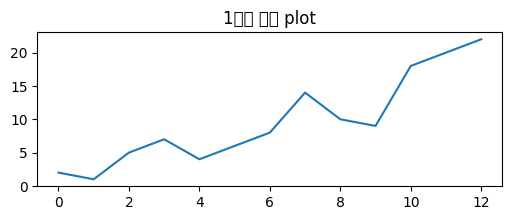

In [43]:
# ── Matplotlib ────────────────────────────────────────────────────
# 그래프·축·스타일

import numpy as np
import matplotlib.pyplot as plt

a = np.array([2, 1, 5, 7, 4, 6, 8, 14, 10, 9, 18, 20, 22])
fig, ax = plt.subplots(figsize=(6, 2))
ax.plot(a)
ax.set_title("1차원 배열 plot")
plt.show()


# XIV. 선형대수·격자(Quickstart)

## 14.1 행렬 곱과 요소별 곱

### 문제 44. `@` · `*` 차이

- **`A * B`**: 같은 shape일 때 요소별 곱.

- **`A @ B`**: 행렬 곱(내적 규칙). `np.matmul`과 동일.


In [44]:
# ── 내적·행렬곱 ────────────────────────────────────────────────────────
# 스칼라·벡터·행렬 연산

import numpy as np

A = np.array([[1, 1], [0, 1]])
B = np.array([[2, 0], [3, 4]])
print("요소별 곱:\n", A * B)
print("행렬 곱:\n", A @ B)


요소별 곱:
 [[2 0]
 [0 4]]
행렬 곱:
 [[5 4]
 [3 4]]


## 14.2 `meshgrid`

### 문제 45. 2변수 함수를 격자 위에서 계산

- **`np.meshgrid(x, y)`**: 좌표 격자 `X, Y`를 만들어 `f(X,Y)`처럼 벡터화합니다.


In [45]:
# ── 격자 좌표 ─────────────────────────────────────────────────────────
# `meshgrid`로 2D 그리드

import numpy as np

x = np.linspace(0, 1, 3)
y = np.linspace(0, 1, 4)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2
print("Z shape:", Z.shape)
print(Z)


Z shape: (4, 3)
[[0.         0.25       1.        ]
 [0.11111111 0.36111111 1.11111111]
 [0.44444444 0.69444444 1.44444444]
 [1.         1.25       2.        ]]


## 14.3 `np.fromfunction`

### 문제 46. 인덱스로 값 생성

- **`np.fromfunction(f, shape)`**: 각 좌표에 `f(i,j,...)`를 적용해 채웁니다.


In [46]:
# ── 함수 정의 ─────────────────────────────────────────────────────────
# 재사용 가능한 블록

import numpy as np

def f(i, j):
    return 10 * i + j

b = np.fromfunction(f, (3, 4), dtype=int)
print(b)


[[ 0  1  2  3]
 [10 11 12 13]
 [20 21 22 23]]


## 14.4 `np.ix_`

### 문제 47. 서로 다른 1차원으로 브로드캐스트 그리드

- **`np.ix_(a, b, c)`**: 각 벡터를 서로 다른 축에 올려 전체 조합을 연산하기 쉽게 합니다.


In [47]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

a = np.array([2, 3, 4])
b = np.array([8, 5])
c = np.array([5, 4, 6])
ax, bx, cx = np.ix_(a, b, c)
out = ax + bx * cx
print(out.shape)
print(out)


(3, 2, 3)
[[[42 34 50]
  [27 22 32]]

 [[43 35 51]
  [28 23 33]]

 [[44 36 52]
  [29 24 34]]]


# XV. 고급 인덱싱·ufunc

## 15.1 정수 배열 인덱싱

### 문제 48. 정수 배열로 원소를 골라 새 배열

- **`a[idx]`**: `idx`가 배열이면, 나열된 인덱스 위치의 값을 모읍니다.


In [48]:
# ── 배열 생성 ─────────────────────────────────────────────────────────
# `zeros`·`ones`·`arange` 등

import numpy as np

a = np.arange(12) ** 2
i = np.array([1, 1, 3, 8, 5])
print(a[i])
j = np.array([[3, 4], [9, 7]])
print(a[j])


[ 1  1  9 64 25]
[[ 9 16]
 [81 49]]


## 15.2 불리언 마스크로 일괄 대입

### 문제 49. `a[조건] = 값`

- **불리언 마스크 위치**에 한꺼번에 값을 넣을 수 있습니다.


In [49]:
# ── reshape ───────────────────────────────────────────────────────
# 배열 `shape` 변경

import numpy as np

a = np.arange(12).reshape(3, 4)
a[a > 8] = 0
print(a)


[[0 1 2 3]
 [4 5 6 7]
 [8 0 0 0]]


## 15.3 유니버설 함수 `ufunc`

### 문제 50. `np.exp` · `np.sqrt`

- **ufunc**: 배열에 **원소별**로 수학 함수를 적용합니다.


In [50]:
# ── dtype 변환 ──────────────────────────────────────────────────────
# `astype`으로 자료형 변경

import numpy as np

B = np.arange(3)
print(np.exp(B))
print(np.sqrt(B.astype(float)))


[1.         2.71828183 7.3890561 ]
[0.         1.         1.41421356]


## 15.4 누적합 `cumsum`

### 문제 51. `axis` 따라 누적

- **`a.cumsum(axis=1)`**: 행 안에서 왼쪽→오른쪽 누적 합.


In [51]:
# ── reshape ───────────────────────────────────────────────────────
# 배열 `shape` 변경

import numpy as np

b = np.arange(12).reshape(3, 4)
print(b.cumsum(axis=1))


[[ 0  1  3  6]
 [ 4  9 15 22]
 [ 8 17 27 38]]


# XVI. 출력·함수 평가·기타

## 16.1 출력 옵션

### 문제 52. `np.set_printoptions(threshold=...)`

- **`threshold`**: 생략 없이 출력할 최대 원소 개수(너무 큰 배열은 …으로 줄임).


In [52]:
# ── 모듈 임포트 ────────────────────────────────────────────────────────
# NumPy 실습에 쓰는 패키지 로드

import numpy as np

big = np.arange(100)
print(big)
np.set_printoptions(threshold=200)
print("threshold 조정 후 앞부분:", big[:5])
np.set_printoptions(threshold=1000)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
threshold 조정 후 앞부분: [0 1 2 3 4]


## 16.2 `linspace` + `sin`

### 문제 53. 많은 점에서 연속 함수 샘플링

- **`np.linspace` + `np.sin`**: 구간을 촘촘히 나눠 사인 곡선 값을 얻습니다.


In [53]:
# ── 모듈 임포트 ────────────────────────────────────────────────────────
# NumPy 실습에 쓰는 패키지 로드

import numpy as np
from numpy import pi

x = np.linspace(0, 2 * pi, 20)
y = np.sin(x)
print(y.round(3))


[ 0.     0.325  0.614  0.837  0.969  0.997  0.916  0.736  0.476  0.165
 -0.165 -0.476 -0.736 -0.916 -0.997 -0.969 -0.837 -0.614 -0.325 -0.   ]


## 16.3 `np.array` 호출 실수 방지

### 문제 54. 반드시 **하나의 시퀀스**만 넘기기

- **잘못된 예**: `np.array(1, 2, 3)` — 여러 스칼라를 나열하면 TypeError.

- **올바른 예**: `np.array([1, 2, 3])`.


In [54]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

# np.array(1, 2, 3)  # TypeError
a = np.array([1, 2, 3])
print(a)


[1 2 3]


## 16.4 단위행렬 `eye`·`identity`

### 문제 55. `np.eye` / `np.identity`

- **`np.eye(N)`**: N×N 대각이 1인 행렬.

- **`np.identity`**: 주로 정사각 단위행렬.


In [55]:
# ── 모듈 임포트 ────────────────────────────────────────────────────────
# NumPy 실습에 쓰는 패키지 로드

import numpy as np

print(np.eye(3))
print(np.identity(2, dtype=int))


[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[[1 0]
 [0 1]]


## 16.5 `column_stack`

### 문제 56. 1차원 두 벡터를 열로 붙이기

- **`np.column_stack((a,b))`**: 길이가 같은 1차원을 열로 쌓아 `(n,2)` 형태로.


In [56]:
# ── 배열 이어붙이기 ──────────────────────────────────────────────────────
# 축 방향 결합

import numpy as np

a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])
print(np.column_stack((a, b)))


[[1. 4.]
 [2. 5.]
 [3. 6.]]


## 16.6 `np.where`

### 문제 57. 조건에 따라 두 배열/값 중 선택

- **`np.where(cond, x, y)`**: `cond`가 True면 `x`, False면 `y` 원소를 고릅니다.


In [57]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

a = np.array([-1, 0, 2, 3])
print(np.where(a > 0, a, 0))


[0 0 2 3]


## 16.7 `np.clip`

### 문제 58. 최솟값·최댓값 범위로 잘라내기

- **`np.clip(a, min, max)`**: `a`의 각 원소를 `[min,max]`로 제한.


In [58]:
# ── ndarray 생성 ────────────────────────────────────────────────────
# 리스트 등에서 배열 만들기

import numpy as np

a = np.array([0, 1, 5, 10])
print(np.clip(a, 2, 8))


[2 2 5 8]


## 16.8 다차원 출력 모양

### 문제 59. 마지막 축이 가장 빨리 바뀌는 방향

- **출력 규칙**: 마지막 축이 가로로, 그 앞 축이 세로·블록 순으로 펼쳐집니다.


In [59]:
# ── reshape ───────────────────────────────────────────────────────
# 배열 `shape` 변경

import numpy as np

c = np.arange(24).reshape(2, 3, 4)
print(c)


[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]


# VI. 배열 결합·분할

## 6.2 `np.stack`

### 문제 60. 새 축 방향으로 배열을 겹쳐 쌓기

- **`np.stack(arrays, axis=0)`**: 리스트의 배열들을 **새 축**으로 쌓습니다(`vstack`과 다름).

- **`axis`**: 쌓을 위치(0이면 가장 앞에 블록 축이 생김).


In [60]:
# ── 배열 이어붙이기 ──────────────────────────────────────────────────────
# 축 방향 결합

import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
s0 = np.stack([a, b], axis=0)  # (2, 3)
s1 = np.stack([a, b], axis=1)  # (3, 2)
print("axis=0:\n", s0)
print("axis=1:\n", s1)


axis=0:
 [[1 2 3]
 [4 5 6]]
axis=1:
 [[1 4]
 [2 5]
 [3 6]]


# XVII. 정형 데이터 가공

## pandas 1회 로드 → NumPy 가공

### 문제 61 한 번만 로드 - `정형_csv`·`read_csv`·`to_numpy()` (`X`, `SRV`, `ISSUE_CAT`)

- **이 셀에서만** `Path` / `정형_csv` / **`pandas.read_csv`** / **`to_numpy()`** 를 씁니다.

- **`X`**: 군수품 CSV — `stock_level`, `avg_daily_usage`, `weekend_usage_ratio`, `delivery_lead_time`.

- **`SRV`**: 서버 CSV — 열 순서 `cpu_usage`, `memory_usage`, `fix_required`, `fix_duration_hours`.

- **`ISSUE_CAT`**: 서버 `issue_category` 문자열 1차원 배열.

- **문제 62~70**은 **`import numpy as np` + NumPy API만** 사용합니다(추가 `read_csv` 없음).


In [61]:
# ── 파일 적재 ─────────────────────────────────────────────────────────
# CSV·Excel을 DataFrame으로 읽기

from pathlib import Path
import unicodedata as ud
import numpy as np
import pandas as pd


def 정형_dir() -> Path:
    cwd = Path.cwd().resolve()
    for base in (cwd, cwd / "소집교육", cwd.parent):
        for d in (base / "dataset" / "정형", base / "소집교육" / "dataset" / "정형"):
            if d.is_dir():
                return d
    raise FileNotFoundError("dataset/정형 폴더를 찾지 못했습니다. cwd=" + str(cwd))


def 정형_csv(키워드: str) -> Path:
    for f in 정형_dir().glob("*.csv"):
        if 키워드 in ud.normalize("NFC", f.name):
            return f
    raise FileNotFoundError(f"키워드 {키워드!r}에 맞는 CSV가 없습니다.")

# ----- 아래부터 정형 데이터 → ndarray (한 번만) -----
path_g = 정형_csv("군수품")
cols_g = [
    "stock_level",
    "avg_daily_usage",
    "weekend_usage_ratio",
    "delivery_lead_time",
]
df_g = pd.read_csv(path_g, encoding="utf-8-sig", usecols=cols_g)
X = df_g.to_numpy(dtype=float)

path_s = 정형_csv("서버")
cols_s_num = ["cpu_usage", "memory_usage", "fix_required", "fix_duration_hours"]
df_s = pd.read_csv(path_s, encoding="utf-8-sig", usecols=cols_s_num + ["issue_category"])
SRV = df_s[cols_s_num].to_numpy(dtype=float)
ISSUE_CAT = df_s["issue_category"].astype(str).to_numpy()

print("X (군수품):", X.shape, "| SRV (서버 수치):", SRV.shape, "| ISSUE_CAT:", ISSUE_CAT.shape)
print("X[:2]:\n", X[:2])


X (군수품): (11000, 4) | SRV (서버 수치): (11000, 4) | ISSUE_CAT: (11000,)
X[:2]:
 [[22.    4.6   0.34  4.  ]
 [28.    5.7   0.33  5.  ]]


### 문제 62 열 슬라이스 - `X[:, i:j]`

- **문제 61 실행 후** `X`의 열 인덱스로 일부 특성만 잘라 씁니다.

- **`ndarray` 슬라이스**는 뷰일 수 있으므로, 수정이 필요하면 **`copy()`** 하세요.


In [62]:
# ── 모듈 임포트 ────────────────────────────────────────────────────────
# NumPy 실습에 쓰는 패키지 로드

import numpy as np

# 문제 61 실행 후
X_sub = X[:, :2]  # stock_level, avg_daily_usage 만
print("shape:", X_sub.shape)
print(X_sub[:3])


shape: (11000, 2)
[[22.   4.6]
 [28.   5.7]
 [19.   4. ]]


### 문제 63 열 결합·파생 - `np.hstack`

- **`np.hstack`**, **`np.column_stack`**: 가로로 배열을 붙여 특성을 늘립니다.

- 예: 기존 열 + 제곱항(비선형 특성)을 NumPy만으로 만듭니다.


In [63]:
# ── 배열 이어붙이기 ──────────────────────────────────────────────────────
# 축 방향 결합

import numpy as np

# 문제 61 실행 후 — 첫 열(stock_level)의 제곱을 특성으로 추가
stock = X[:, :1]
X_aug = np.hstack([X, stock**2])
print("원본 열 수:", X.shape[1], "→ 확장 후:", X_aug.shape[1])
print(X_aug[:2].round(4))


원본 열 수: 4 → 확장 후: 5
[[2.20e+01 4.60e+00 3.40e-01 4.00e+00 4.84e+02]
 [2.80e+01 5.70e+00 3.30e-01 5.00e+00 7.84e+02]]


### 문제 64 결측 행 제거 - `np.isnan`·불리언 마스크

- **`np.any(np.isnan(a), axis=1)`**: 행에 `nan`이 하나라도 있으면 True.

- **`a[mask]`**: 결측이 없는 행만 남깁니다.


In [64]:
# ── 뷰 vs 복사 ───────────────────────────────────────────────────────
# 슬라이스와 `copy`

import numpy as np

# 문제 61 실행 후 — 연습용으로 일부에 nan 삽입
D = X.copy()
D[:5, 0] = np.nan
ok = ~np.any(np.isnan(D), axis=1)
cleaned = D[ok]
print("원본 행:", X.shape[0], "| 결측 행 제거 후:", cleaned.shape[0])
print(cleaned[:2])


원본 행: 11000 | 결측 행 제거 후: 10995
[[ 8.    1.8   0.45  6.  ]
 [29.    5.9   0.43  6.  ]]


### 문제 65 조건 행 필터 - `SRV[불리언]`

- **`SRV` 열 순서**: 0=`cpu_usage`, 1=`memory_usage`, 2=`fix_required`, 3=`fix_duration_hours`.

- **`SRV[:, k] > 값`**, **`SRV[:, k] == 1`** 형태로 마스크를 만듭니다.


In [65]:
# ── 모듈 임포트 ────────────────────────────────────────────────────────
# NumPy 실습에 쓰는 패키지 로드

import numpy as np

# 문제 61 실행 후
high_cpu = SRV[SRV[:, 0] > 35.0]
need_fix = SRV[SRV[:, 2] == 1.0]
print("CPU>35 인 행:", high_cpu.shape[0], "| fix_required==1:", need_fix.shape[0])
print("고CPU 샘플 (cpu, mem, fix, 시간):\n", high_cpu[:3])


CPU>35 인 행: 2386 | fix_required==1: 5541
고CPU 샘플 (cpu, mem, fix, 시간):
 [[41.   27.9   1.    4.12]
 [36.1  24.    0.    5.43]
 [40.2  18.8   0.    1.48]]


### 문제 66 열 방향 표준화 - z-score (`np.mean`·`np.std`)

- **`np.mean(a, axis=0)`**, **`np.std(a, axis=0, ddof=0)`** 로 열별 통계.

- **`(X - mu) / sigma`** 는 브로드캐스팅으로 각 열에 적용됩니다.


In [66]:
# ── 뷰 vs 복사 ───────────────────────────────────────────────────────
# 슬라이스와 `copy`

import numpy as np

# 문제 61 실행 후 — 앞 500행만 (속도·메모리)
sub = X[:500].copy()
mu = np.mean(sub, axis=0)
sig = np.std(sub, axis=0, ddof=0)
sig_safe = np.where(sig < 1e-8, 1.0, sig)
Z = (sub - mu) / sig_safe
print("표준화 후 (앞 3행):\n", Z[:3].round(4))
print("열별 평균(≈0):", Z.mean(axis=0).round(6))


표준화 후 (앞 3행):
 [[-0.0953 -0.0289  0.3423 -0.1754]
 [ 0.5131  0.4945  0.2561  0.4841]
 [-0.3994 -0.3144 -0.4333  1.1436]]
열별 평균(≈0): [ 0. -0.  0.  0.]


### 문제 67 순위 - `np.argsort` (조치 시간 상위)

- **`np.argsort(-SRV[:, 3])`**: `fix_duration_hours` 내림차순 인덱스.

- **`SRV[order]`** 로 재배열한 뒤 앞 k행만 보면 됩니다.


In [67]:
# ── 정렬·인덱스 ────────────────────────────────────────────────────────
# 순서·최댓값 위치

import numpy as np

# 문제 61 실행 후 — 열 3 = fix_duration_hours
order = np.argsort(-SRV[:, 3])
top10 = SRV[order[:10]]
print("조치시간 긴 순 상위 10행 (cpu, mem, fix_req, hours):\n", top10)


조치시간 긴 순 상위 10행 (cpu, mem, fix_req, hours):
 [[17.1        31.1         0.         11.79      ]
 [87.37654014 91.85654227  0.         11.56      ]
 [31.         18.7         1.         11.47      ]
 [26.         24.5         0.         11.11      ]
 [20.         37.7         1.         10.99      ]
 [22.4        27.1         1.         10.94      ]
 [38.3        68.5         1.         10.67      ]
 [18.4        29.7         0.         10.43      ]
 [12.4        43.8         1.         10.36      ]
 [13.2        26.2         0.         10.29      ]]


### 문제 68 범주 → 정수 라벨 - `np.unique`·`return_inverse`

- **`ISSUE_CAT`**: 문제 61에서 만든 1차원 문자열 배열.

- **`return_inverse`**: 각 행의 카테고리를 0..K-1 정수로 바꿉니다.


In [68]:
# ── 모듈 임포트 ────────────────────────────────────────────────────────
# NumPy 실습에 쓰는 패키지 로드

import numpy as np

# 문제 61 실행 후
uniq, inv = np.unique(ISSUE_CAT, return_inverse=True)
print("고유 카테고리:", uniq)
print("정수 코드 (앞 10개):", inv[:10])
print("고유 개수:", len(uniq))


고유 카테고리: ['CPU과부하' '디스크' '없음' '전력']
정수 코드 (앞 10개): [1 0 0 2 0 3 3 3 1 1]
고유 개수: 4


### 문제 69 셔플·분할 - `permutation` (train/valid)

- **`rng.permutation(n)`**으로 행 인덱스를 섞은 뒤 **`X[idx]`** 로 동일 순서 적용.

- 검증 비율은 **`int(n * 0.7)`** 등으로 나눕니다.


In [69]:
# ── 난수·표본 ─────────────────────────────────────────────────────────
# `np.random` 분포·셔플

import numpy as np

# 문제 61 실행 후
rng = np.random.default_rng(42)
n = X.shape[0]
idx = rng.permutation(n)
split = int(n * 0.7)
train, valid = X[idx[:split]], X[idx[split:]]
print("train:", train.shape, "valid:", valid.shape)
print(train[:2])


train: (7699, 4) valid: (3301, 4)
[[22.    4.6   0.25  6.  ]
 [22.    4.5   0.28  2.  ]]


### 문제 70 설계행렬 - 절편·다항항 (`np.column_stack`)

- **`X[:, 0]`**, **`X[:, 1]`** 을 `stock_level`, `avg_daily_usage` 로 두고 **`[1, s, u, s**2]`** 형태로 쌓습니다.

- 회귀·선형모델에서 흔한 **절편 + 비선형 항** 패턴입니다.


In [70]:
# ── 배열 이어붙이기 ──────────────────────────────────────────────────────
# 축 방향 결합

import numpy as np

# 문제 61 실행 후 — 앞 200행만 예시
sub = X[:200]
s = sub[:, 0]
u = sub[:, 1]
bias = np.ones(len(s))
design = np.column_stack([bias, s, u, s**2])
print("설계행렬 shape:", design.shape)
print(design[:3].round(4))


설계행렬 shape: (200, 4)
[[  1.   22.    4.6 484. ]
 [  1.   28.    5.7 784. ]
 [  1.   19.    4.  361. ]]


---

## 참고 링크

- [Absolute beginners](https://numpy.org/doc/stable/user/absolute_beginners.html)
- [Quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- [Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html)
- [Copies and views](https://numpy.org/doc/stable/user/basics.copies.html)
